# gensort - Experiment 3: OVC Comparison Analysis


In [1]:
import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# Configuration
LOG_DIR = './result'
OUTPUT_DIR = './exp3_output'

# ==========================================
# PLOTTING
# ==========================================
plt.style.use('../../logs/custom_plt_style.mplstyle')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

## 1. Log File Parser

In [2]:
def parse_log_file_with_io(filepath):
    """Parse a single log file and extract all metrics including detailed I/O."""
    filename = os.path.basename(filepath)
    
    # Parse filename to extract experiment parameters
    exp_match = re.search(r'(Exp\d+\.?\d*)', filename)  # Support Exp3.1 format
    thr_match = re.search(r'Thr(\d+)', filename)
    mem_match = re.search(r'Mem(\d+)GB', filename)
    imb_match = re.search(r'Imbalance([\d.]+)', filename)
    
    if not (exp_match and thr_match and mem_match):
        return None
    
    result = {
        'experiment': exp_match.group(1),
        'threads': int(thr_match.group(1)),
        'memory_gb': int(mem_match.group(1)),
        'imbalance_factor': float(imb_match.group(1)) if imb_match else None,
        'filename': filename
    }
    
    # Parse metrics from log file
    with open(filepath, 'r') as f:
        content = f.read()
        
        # Find the [avg] line in Benchmark Results Summary
        avg_match = re.search(
            r'(\w+)\[avg\]\s+(\S+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)',
            content
        )
        
        if avg_match:
            result['run_size_mb'] = float(avg_match.group(2))
            result['num_runs'] = int(avg_match.group(3))
            result['gen_threads'] = int(avg_match.group(4))
            result['merge_threads'] = int(avg_match.group(5))
            result['total_time'] = float(avg_match.group(6))
            result['rungen_time'] = float(avg_match.group(7))
            result['merge_time'] = float(avg_match.group(8))
            result['entries'] = int(avg_match.group(9))
            result['throughput'] = float(avg_match.group(10))
            result['read_mb'] = float(avg_match.group(11))
            result['write_mb'] = float(avg_match.group(12))
        
        # Extract read amplification factor
        read_amp_match = re.search(r'Read amplification factor: ([\d.]+)x', content)
        if read_amp_match:
            result['read_amplification'] = float(read_amp_match.group(1))
        
        # Count merge passes
        merge_passes_match = re.search(r'Total merge passes: (\d+)', content)
        if merge_passes_match:
            result['merge_passes'] = int(merge_passes_match.group(1))
        else:
            result['merge_passes'] = 1
        
        # Extract partition imbalance - WEIGHTED average by partition size
        # Each merge operation has 5 columns: PAvg, PMax, Imbal, Slow, Fast
        # PAvg is at positions 0, 5, 10, 15 (0-indexed)
        # Imbal is at positions 2, 7, 12, 17 (0-indexed)
        merge_section = content.split('Merge Operations Summary')[-1]
        avg_line_match = re.search(r'\[avg\]\s+([\d.\s]+)', merge_section)
        if avg_line_match:
            # Extract all numbers from the [avg] line
            numbers_str = avg_line_match.group(1).strip()
            numbers = [float(n) for n in numbers_str.split()]
            
            # Extract partition sizes and imbalance values
            partition_sizes = []
            imbalances = []
            for i in range(0, len(numbers), 5):
                if i + 2 < len(numbers):
                    partition_sizes.append(numbers[i])      # M1PAvg, M2PAvg, M3PAvg, M4PAvg
                    imbalances.append(numbers[i + 2])       # M1Imbal, M2Imbal, M3Imbal, M4Imbal
            
            # Calculate weighted average: sum(PAvg * Imbal) / sum(PAvg)
            if partition_sizes and imbalances:
                weighted_sum = sum(p * i for p, i in zip(partition_sizes, imbalances))
                total_weight = sum(partition_sizes)
                result['partition_imbalance'] = weighted_sum / total_weight
        
        # Extract detailed I/O statistics from [avg] line
        io_section = content.split('Detailed I/O Statistics')[-1]
        io_avg_match = re.search(
            r'\[avg\]\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?',
            io_section
        )
        
        if io_avg_match:
            result['rg_read_mb'] = float(io_avg_match.group(1))
            result['rg_write_mb'] = float(io_avg_match.group(2))
            result['m1_read_mb'] = float(io_avg_match.group(3))
            result['m1_write_mb'] = float(io_avg_match.group(4))
            result['m2_read_mb'] = float(io_avg_match.group(5)) if io_avg_match.group(5) else 0.0
            result['m2_write_mb'] = float(io_avg_match.group(6)) if io_avg_match.group(6) else 0.0
            result['m3_read_mb'] = float(io_avg_match.group(7)) if io_avg_match.group(7) else 0.0
            result['m3_write_mb'] = float(io_avg_match.group(8)) if io_avg_match.group(8) else 0.0
            result['m4_read_mb'] = float(io_avg_match.group(9)) if io_avg_match.group(9) else 0.0
            result['m4_write_mb'] = float(io_avg_match.group(10)) if io_avg_match.group(10) else 0.0
            
            # Calculate total I/O
            result['total_io_mb'] = (result['rg_read_mb'] + result['rg_write_mb'] + 
                                     result['m1_read_mb'] + result['m1_write_mb'] +
                                     result['m2_read_mb'] + result['m2_write_mb'] +
                                     result['m3_read_mb'] + result['m3_write_mb'] +
                                     result['m4_read_mb'] + result['m4_write_mb'])
    
    return result if 'total_time' in result else None


def load_all_experiments(log_dir):
    """Load all log files and organize by experiment."""
    log_files = glob.glob(os.path.join(log_dir, '*.log'))
    
    all_data = []
    for filepath in log_files:
        parsed = parse_log_file_with_io(filepath)
        if parsed:
            all_data.append(parsed)
    
    df = pd.DataFrame(all_data)
    return df


# Load all data
df_all = load_all_experiments(LOG_DIR)
print(f"Loaded {len(df_all)} experiment results")
print(f"\nExperiments found: {sorted(df_all['experiment'].unique())}")

Loaded 51 experiment results

Experiments found: ['Exp1', 'Exp2', 'Exp3', 'Exp3.1', 'Exp4', 'Exp5']


In [3]:
def parse_exp1_subexp_log(filepath):
    """Parse Exp1.1 and Exp1.2 log files with RunGen/Merge thread counts."""
    filename = os.path.basename(filepath)

    # Parse filename: Exp1.1_RunGen40_Merge16_Mem2GB.log
    exp_match = re.search(r'(Exp\d+\.\d+)', filename)
    rungen_match = re.search(r'RunGen(\d+)', filename)
    merge_match = re.search(r'Merge(\d+)', filename)
    mem_match = re.search(r'Mem(\d+)GB', filename)

    if not (exp_match and rungen_match and merge_match and mem_match):
        return None

    result = {
        'experiment': exp_match.group(1),
        'rungen_threads': int(rungen_match.group(1)),
        'merge_threads': int(merge_match.group(1)),
        'memory_gb': int(mem_match.group(1)),
        'filename': filename
    }

    # Parse metrics from log file
    with open(filepath, 'r') as f:
        content = f.read()

        # Find the [avg] line in Benchmark Results Summary
        avg_match = re.search(
            r'(\w+)\[avg\]\s+(\S+)\s+(\d+)\s+(\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)\s+(\d+\.\d+)',
            content
        )

        if avg_match:
            result['run_size_mb'] = float(avg_match.group(2))
            result['num_runs'] = int(avg_match.group(3))
            result['gen_threads'] = int(avg_match.group(4))
            result['merge_threads_actual'] = int(avg_match.group(5))
            result['total_time'] = float(avg_match.group(6))
            result['rungen_time'] = float(avg_match.group(7))
            result['merge_time'] = float(avg_match.group(8))
            result['entries'] = int(avg_match.group(9))
            result['throughput'] = float(avg_match.group(10))
            result['read_mb'] = float(avg_match.group(11))
            result['write_mb'] = float(avg_match.group(12))

        # Extract read amplification factor
        read_amp_match = re.search(r'Read amplification factor: ([\d.]+)x', content)
        if read_amp_match:
            result['read_amplification'] = float(read_amp_match.group(1))

        # Count merge passes
        merge_passes_match = re.search(r'Total merge passes: (\d+)', content)
        if merge_passes_match:
            result['merge_passes'] = int(merge_passes_match.group(1))

        # Extract detailed I/O statistics from [avg] line
        io_section = content.split('Detailed I/O Statistics')[-1]
        io_avg_match = re.search(
            r'\[avg\]\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)\s+([\d.]+)(?:\s+([\d.]+)\s+([\d.]+))?(?:\s+([\d.]+)\s+([\d.]+))?',
            io_section
        )

        if io_avg_match:
            result['rg_read_mb'] = float(io_avg_match.group(1))
            result['rg_write_mb'] = float(io_avg_match.group(2))
            result['m1_read_mb'] = float(io_avg_match.group(3))
            result['m1_write_mb'] = float(io_avg_match.group(4))
            result['m2_read_mb'] = float(io_avg_match.group(5)) if io_avg_match.group(5) else 0.0
            result['m2_write_mb'] = float(io_avg_match.group(6)) if io_avg_match.group(6) else 0.0
            result['m3_read_mb'] = float(io_avg_match.group(7)) if io_avg_match.group(7) else 0.0
            result['m3_write_mb'] = float(io_avg_match.group(8)) if io_avg_match.group(8) else 0.0

            # Calculate total I/O
            result['total_io_mb'] = (result['rg_read_mb'] + result['rg_write_mb'] +
                                     result['m1_read_mb'] + result['m1_write_mb'] +
                                     result['m2_read_mb'] + result['m2_write_mb'] +
                                     result['m3_read_mb'] + result['m3_write_mb'])

    return result if 'total_time' in result else None

In [4]:
# Load Exp1 data for comparison with Exp3.1
print("="*100)
print("EXP1: SCALABILITY TRAP (2GB RAM, Varying Threads) - WITH OVC")
print("="*100)
df_exp1 = df_all[df_all['experiment'] == 'Exp1'].sort_values('threads')
display_cols = ['threads', 'num_runs', 'total_time', 'rungen_time', 'merge_time', 
                'throughput', 'merge_passes', 'read_amplification']
print(df_exp1[display_cols].to_string(index=False))
if not df_exp1.empty:
    print(f"\nOptimal: {df_exp1.loc[df_exp1['total_time'].idxmin(), 'threads']:.0f} threads @ {df_exp1['total_time'].min():.1f}s")
    print(f"Worst: {df_exp1.loc[df_exp1['total_time'].idxmax(), 'threads']:.0f} threads @ {df_exp1['total_time'].max():.1f}s")

EXP1: SCALABILITY TRAP (2GB RAM, Varying Threads) - WITH OVC
 threads  num_runs  total_time  rungen_time  merge_time  throughput  merge_passes  read_amplification
       4       204     2843.91      1876.57      967.35        0.76             1                1.00
       8       408     1764.47      1044.71      719.76        1.22             1                1.00
      16       816     1342.61       757.63      584.97        1.60             1                1.01
      24      1224     1190.00       634.20      555.80        1.80             1                1.01
      32      1632     1304.87       562.60      742.27        1.65             2                1.39
      40      2040     1343.01       486.97      856.04        1.60             3                1.63
      44      2244     1311.05       462.44      848.61        1.64             4                1.71

Optimal: 24 threads @ 1190.0s
Worst: 4 threads @ 2843.9s


In [5]:
# Load Exp2 data (OVC enabled)
print("\n" + "="*100)
print("EXP2: MEMORY CLIFF (Fixed 40 Threads, Varying Memory) - WITH OVC")
print("="*100)
df_exp2 = df_all[df_all['experiment'] == 'Exp2'].sort_values('memory_gb')
display_cols = ['memory_gb', 'num_runs', 'total_time', 'rungen_time', 'merge_time', 
                'throughput', 'merge_passes', 'read_amplification']
print(df_exp2[display_cols].to_string(index=False))
if not df_exp2.empty:
    print(f"\nOptimal: {df_exp2.loc[df_exp2['total_time'].idxmin(), 'memory_gb']:.0f}GB @ {df_exp2['total_time'].min():.1f}s")
    print(f"Worst: {df_exp2.loc[df_exp2['total_time'].idxmax(), 'memory_gb']:.0f}GB @ {df_exp2['total_time'].max():.1f}s")


EXP2: MEMORY CLIFF (Fixed 40 Threads, Varying Memory) - WITH OVC
 memory_gb  num_runs  total_time  rungen_time  merge_time  throughput  merge_passes  read_amplification
         1      4040     1409.92       470.41      939.51        1.52            10                1.98
         4      1040      899.10       449.33      449.76        2.39             1                1.02
         6       720      902.73       450.80      451.94        2.38             1                1.01
         8       560      914.91       459.58      455.34        2.35             1                1.01
        16       280      927.54       474.62      452.92        2.32             1                1.01
        24       200      943.26       494.89      448.37        2.28             1                1.00
        32       160      980.54       525.26      455.28        2.19             1                1.00

Optimal: 4GB @ 899.1s
Worst: 1GB @ 1409.9s


In [6]:
# Load Exp3 data (OVC disabled)
print("\n" + "="*100)
print("EXP3: MEMORY CLIFF (Fixed 40 Threads, Varying Memory) - WITHOUT OVC")
print("="*100)
df_exp3 = df_all[df_all['experiment'] == 'Exp3'].sort_values('memory_gb')
display_cols = ['memory_gb', 'num_runs', 'total_time', 'rungen_time', 'merge_time', 
                'throughput', 'merge_passes', 'read_amplification']
print(df_exp3[display_cols].to_string(index=False))
if not df_exp3.empty:
    print(f"\nOptimal: {df_exp3.loc[df_exp3['total_time'].idxmin(), 'memory_gb']:.0f}GB @ {df_exp3['total_time'].min():.1f}s")
    print(f"Worst: {df_exp3.loc[df_exp3['total_time'].idxmax(), 'memory_gb']:.0f}GB @ {df_exp3['total_time'].max():.1f}s")


EXP3: MEMORY CLIFF (Fixed 40 Threads, Varying Memory) - WITHOUT OVC
 memory_gb  num_runs  total_time  rungen_time  merge_time  throughput  merge_passes  read_amplification
         1      4040     1358.89       438.39      920.50        1.58            10                1.98
         2      2040     1144.61       450.77      693.84        1.88             3                1.63
         4      1040      922.69       485.77      436.92        2.33             1                1.02
         6       720      930.17       494.64      435.53        2.31             1                1.01
         8       560      950.12       513.67      436.46        2.26             1                1.01
        16       280      980.01       543.93      436.08        2.19             1                1.01
        24       200      999.35       557.38      441.96        2.15             1                1.00
        32       160     1073.88       606.37      467.51        2.00             1                

In [7]:
colors = {
    'total': '#1f77b4',
    'rungen': '#2ca02c', 
    'merge': '#d62728',
    'exp2': '#ff7f0e',
    'exp3': '#9467bd',
    'exp4': '#8c564b'
}

### Exp3.1: OVC Scalability Comparison (Exp1 vs Exp3.1)

In [8]:
# Exp3.1: OVC Scalability Comparison - Load and display data
print("="*100)
print("EXP3.1: NON-OVC SCALABILITY TEST (2GB RAM, Varying Threads)")
print("="*100)
df_exp3_1 = df_all[df_all['experiment'] == 'Exp3.1'].sort_values('threads')
display_cols = ['threads', 'num_runs', 'total_time', 'rungen_time', 'merge_time', 
                'throughput', 'merge_passes', 'read_amplification']
print(df_exp3_1[display_cols].to_string(index=False))

if len(df_exp3_1) > 0:
    print(f"\nOptimal: {df_exp3_1.loc[df_exp3_1['total_time'].idxmin(), 'threads']:.0f} threads @ {df_exp3_1['total_time'].min():.1f}s")
    print(f"Worst: {df_exp3_1.loc[df_exp3_1['total_time'].idxmax(), 'threads']:.0f} threads @ {df_exp3_1['total_time'].max():.1f}s")
    
    # Compare with Exp1 (OVC enabled)
    print("\n" + "="*100)
    print("COMPARISON: OVC vs NON-OVC SCALABILITY")
    print("="*100)
    
    # Merge Exp1 and Exp3.1 data
    comparison = pd.merge(
        df_exp1[['threads', 'total_time', 'rungen_time', 'merge_time', 'throughput']],
        df_exp3_1[['threads', 'total_time', 'rungen_time', 'merge_time', 'throughput']],
        on='threads', suffixes=('_ovc', '_no_ovc')
    )
    comparison['speedup_pct'] = ((comparison['total_time_no_ovc'] / comparison['total_time_ovc']) - 1) * 100
    
    print(comparison[['threads', 'total_time_ovc', 'total_time_no_ovc', 'speedup_pct']].to_string(index=False))
    print(f"\nAverage OVC speedup: {comparison['speedup_pct'].mean():.1f}%")
    print(f"Best OVC speedup: {comparison['speedup_pct'].max():.1f}% at {comparison.loc[comparison['speedup_pct'].idxmax(), 'threads']:.0f} threads")
    print(f"Worst OVC speedup: {comparison['speedup_pct'].min():.1f}% at {comparison.loc[comparison['speedup_pct'].idxmin(), 'threads']:.0f} threads")
else:
    print("\n⚠️  No Exp3.1 data found. Make sure Exp3.1 log files are in the result directory.")

EXP3.1: NON-OVC SCALABILITY TEST (2GB RAM, Varying Threads)
 threads  num_runs  total_time  rungen_time  merge_time  throughput  merge_passes  read_amplification
       4       204     3065.86      2131.79      934.07        0.70             1                1.00
       8       408     1698.75      1066.44      632.31        1.26             1                1.00
      16       816     1244.61       708.96      535.65        1.73             1                1.01
      24      1224     1074.74       588.00      486.73        2.00             1                1.01
      32      1632     1258.90       542.94      715.96        1.71             2                1.39
      40      2040     1290.42       507.66      782.76        1.66             3                1.63
      44      2244     1248.60       458.22      790.39        1.72             4                1.71

Optimal: 24 threads @ 1074.7s
Worst: 4 threads @ 3065.9s

COMPARISON: OVC vs NON-OVC SCALABILITY
 threads  total_time_ovc  

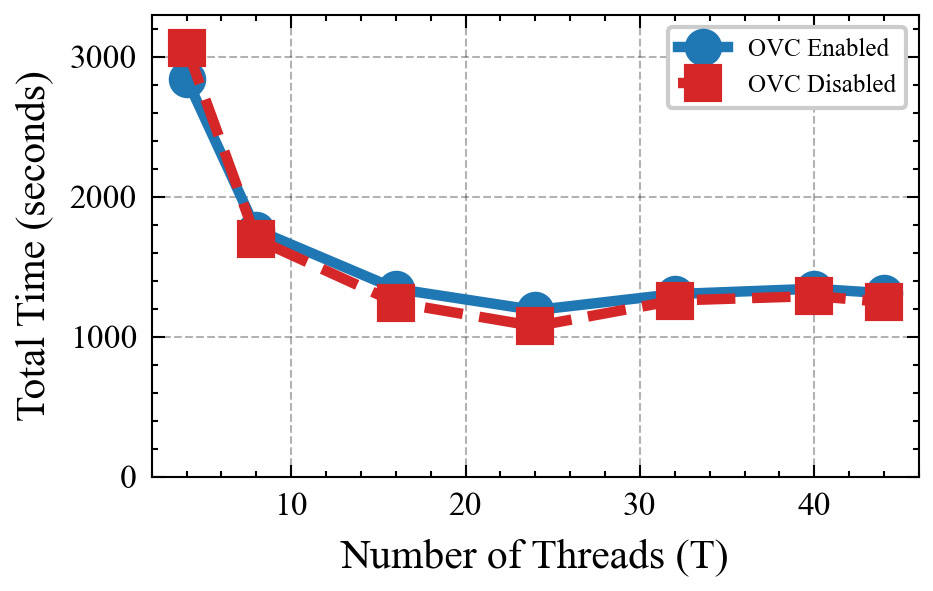

In [9]:
# Exp3.1 Plot 1: Total Time Comparison
if len(df_exp3_1) > 0:
    fig, ax = plt.subplots()
    
    df_exp1_sorted = df_exp1.sort_values('threads')
    df_exp3_1_sorted = df_exp3_1.sort_values('threads')
    threads = df_exp1_sorted['threads'].values
    
    ax.plot(threads, df_exp1_sorted['total_time'], 'o-', lw=2.5, markersize=8, 
             color='#1f77b4', label='OVC Enabled')
    ax.plot(threads, df_exp3_1_sorted['total_time'], 's--', lw=2.5, markersize=8, 
             color='#d62728', label='OVC Disabled')
    ax.set_xlabel('Number of Threads (T)')
    ax.set_ylabel('Total Time (seconds)')
    # ax.set_title('Scalability: OVC vs Non-OVC (2GB RAM)', fontweight='bold', fontsize=13)
    ax.legend(loc='best')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_ylim(bottom=0, top=3300)
    
    plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp3_1_total_time.png'), dpi=300)
    plt.show()


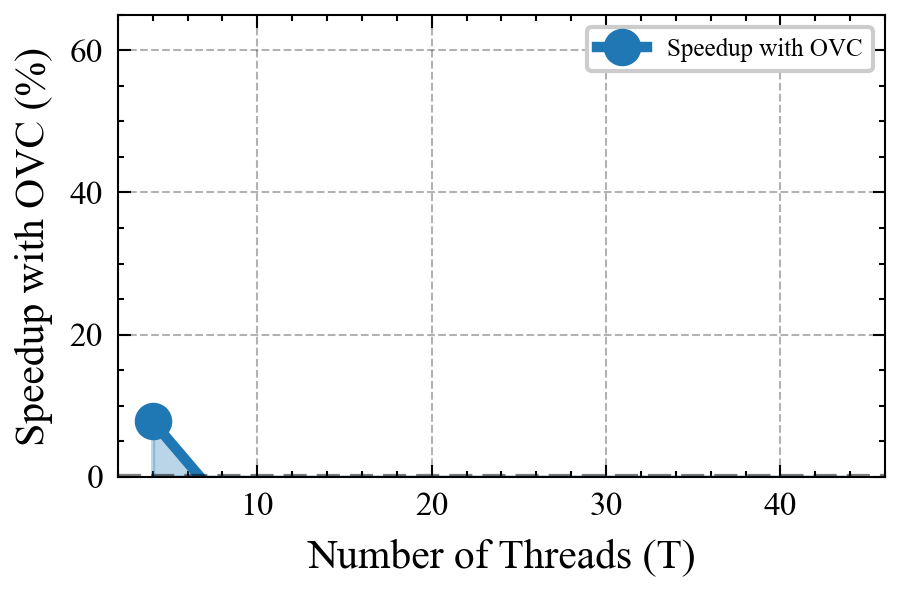

In [10]:
# Exp3.1 Plot 2: Speedup Percentage
if len(df_exp3_1) > 0:
    fig, ax = plt.subplots()
    
    df_exp1_sorted = df_exp1.sort_values('threads')
    df_exp3_1_sorted = df_exp3_1.sort_values('threads')
    threads = df_exp1_sorted['threads'].values
    
    # Calculate speedup with OVC (positive = OVC is faster)
    speedup_pct = ((df_exp3_1_sorted['total_time'].values / df_exp1_sorted['total_time'].values) - 1) * 100
    
    ax.plot(threads, speedup_pct, 'o-', lw=2.5, markersize=8, color='#1f77b4', label='Speedup with OVC')
    ax.axhline(y=0, color='black', linestyle='--', lw=1.5, alpha=0.5)
    ax.fill_between(threads, 0, speedup_pct, alpha=0.3, color='#1f77b4')
    
    ax.set_xlabel('Number of Threads (T)')
    ax.set_ylabel('Speedup with OVC (%)')
    # ax.set_title('OVC Performance Benefit by Thread Count', fontweight='bold', fontsize=13)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.legend(loc='best')
    ax.set_ylim(bottom=0, top=65)
    
    plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp3_1_speedup.png'), dpi=300)
    plt.show()


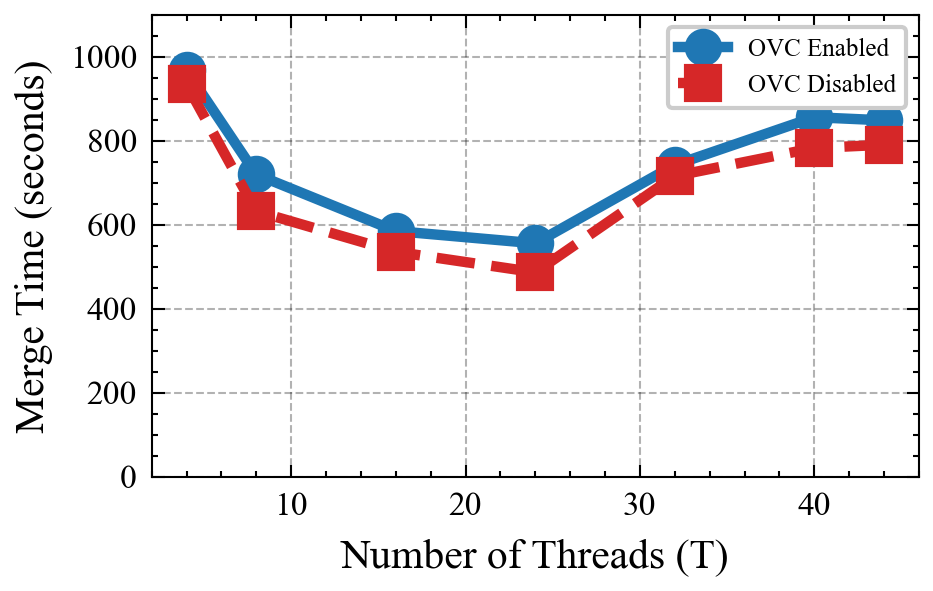

In [11]:
# Exp3.1 Plot 3: Merge Time Comparison
if len(df_exp3_1) > 0:
    fig, ax = plt.subplots()
    
    df_exp1_sorted = df_exp1.sort_values('threads')
    df_exp3_1_sorted = df_exp3_1.sort_values('threads')
    threads = df_exp1_sorted['threads'].values
    
    ax.plot(threads, df_exp1_sorted['merge_time'], 'o-', lw=2.5, markersize=8, 
             color='#1f77b4', label='OVC Enabled')
    ax.plot(threads, df_exp3_1_sorted['merge_time'], 's--', lw=2.5, markersize=8, 
             color='#d62728', label='OVC Disabled')
    ax.set_xlabel('Number of Threads (T)')
    ax.set_ylabel('Merge Time (seconds)')
    # ax.set_title('Merge Phase: OVC Impact', fontweight='bold', fontsize=13)
    ax.legend(loc='best')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_ylim(bottom=0, top=1100)
    
    # plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp3_1_merge_time.png'), dpi=300)
    plt.show()


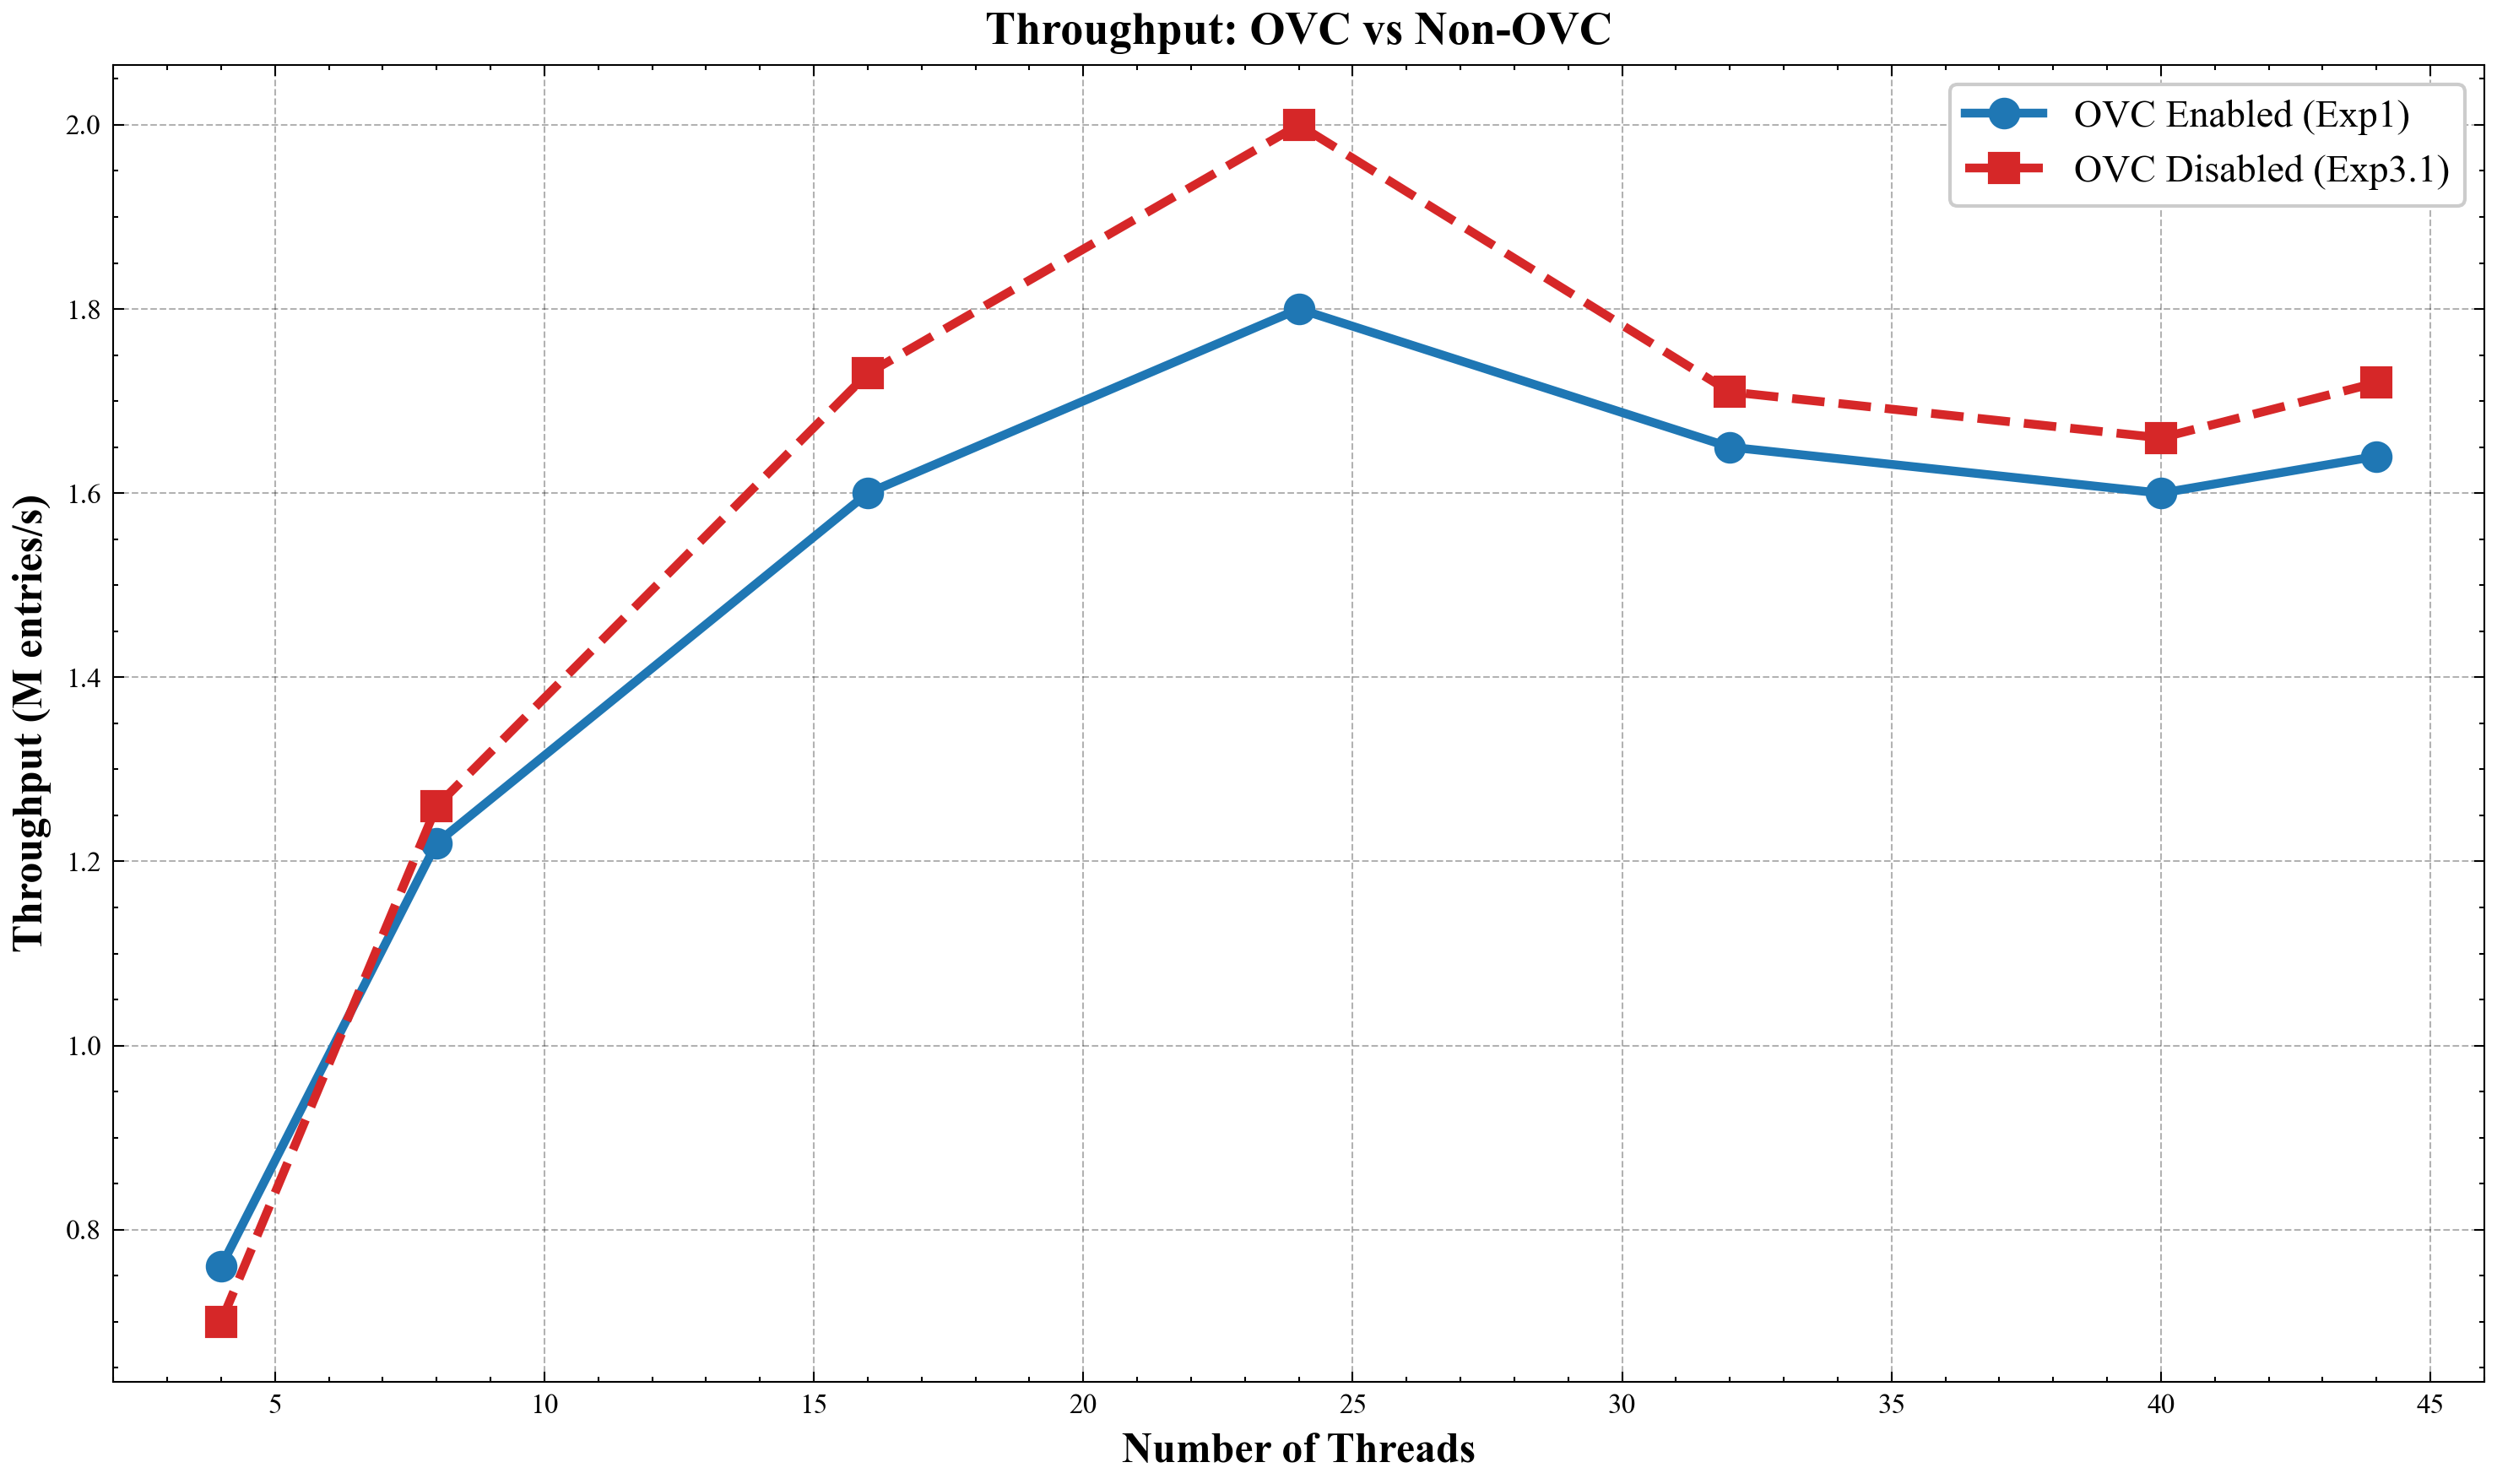


📊 Exp3.1 Insight: OVC provides -3.6% average speedup across thread counts in scalability tests.


In [12]:
# Exp3.1 Plot 4: Throughput Comparison
if len(df_exp3_1) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    df_exp1_sorted = df_exp1.sort_values('threads')
    df_exp3_1_sorted = df_exp3_1.sort_values('threads')
    threads = df_exp1_sorted['threads'].values
    
    ax.plot(threads, df_exp1_sorted['throughput'], 'o-', lw=2.5, markersize=8, 
             color='#1f77b4', label='OVC Enabled (Exp1)')
    ax.plot(threads, df_exp3_1_sorted['throughput'], 's--', lw=2.5, markersize=8, 
             color='#d62728', label='OVC Disabled (Exp3.1)')
    ax.set_xlabel('Number of Threads', fontweight='bold', fontsize=12)
    ax.set_ylabel('Throughput (M entries/s)', fontweight='bold', fontsize=12)
    ax.set_title('Throughput: OVC vs Non-OVC', fontweight='bold', fontsize=13)
    ax.legend(loc='best', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp3_1_throughput.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    speedup_pct = ((df_exp3_1_sorted['total_time'].values / df_exp1_sorted['total_time'].values) - 1) * 100
    print(f"\n📊 Exp3.1 Insight: OVC provides {speedup_pct.mean():.1f}% average speedup across thread counts in scalability tests.")


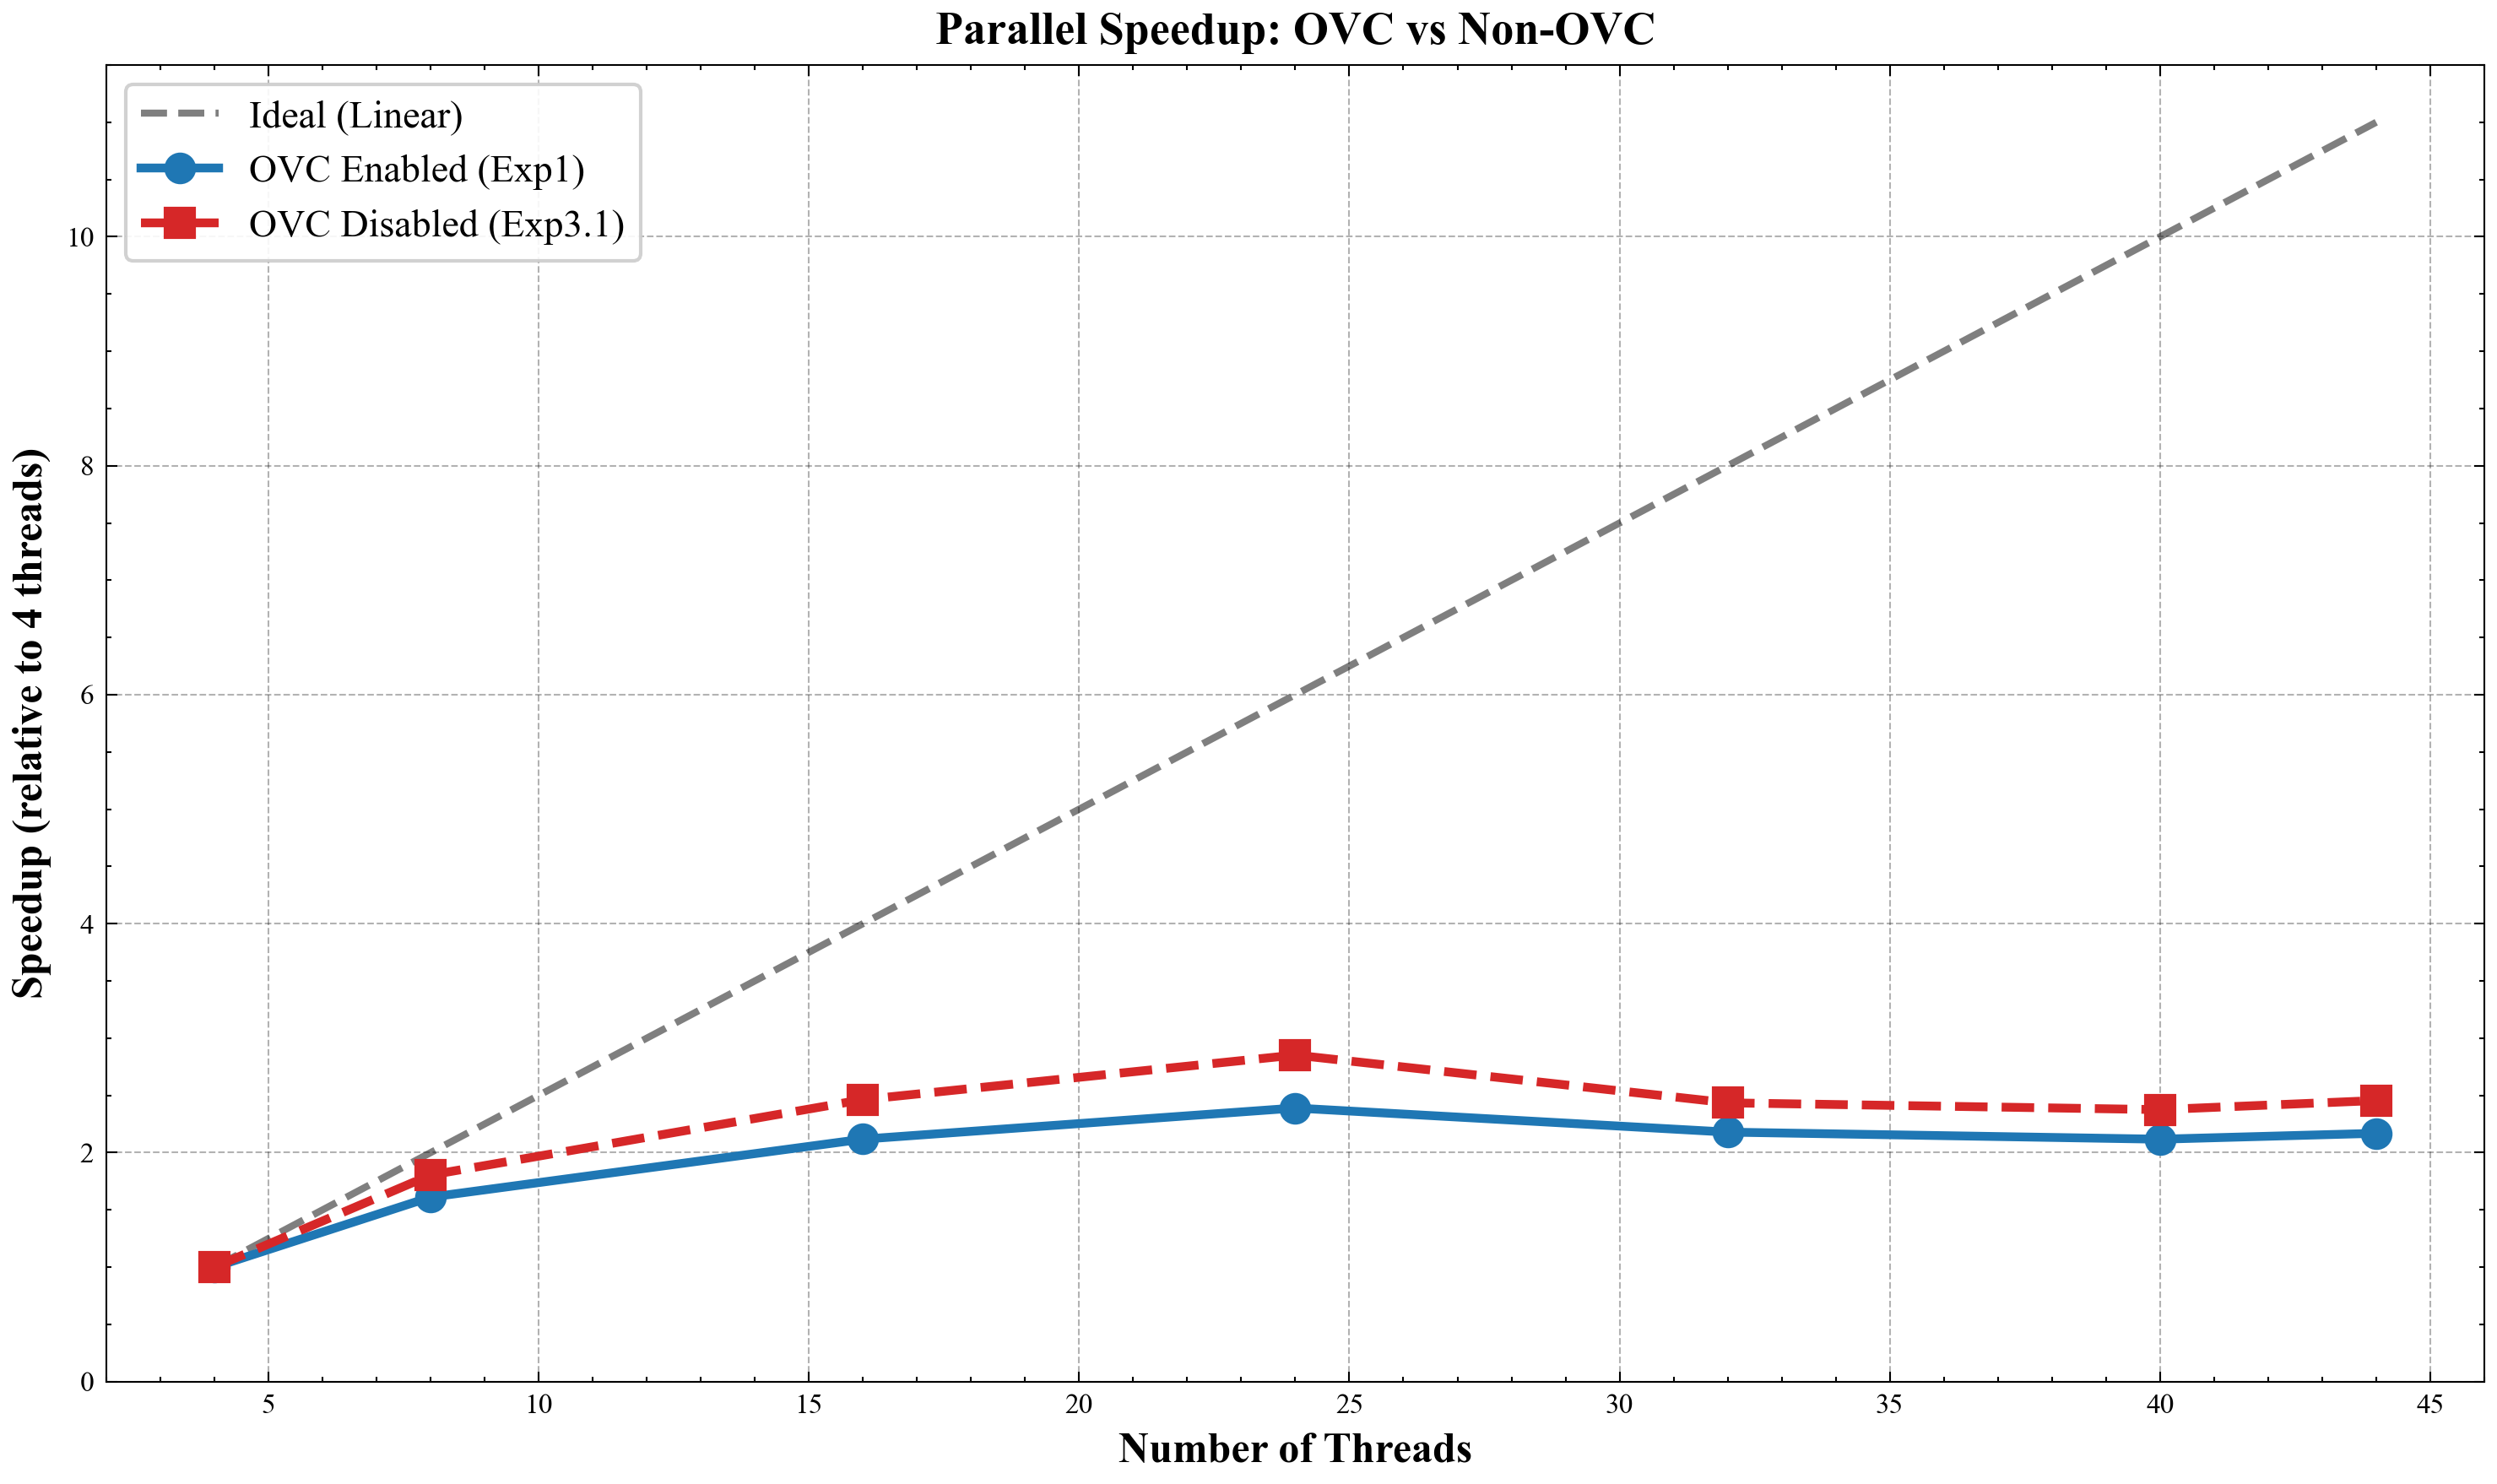

In [13]:
# Exp3.1 Plot 5: Speedup Comparison
if len(df_exp3_1) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    df_exp1_sorted = df_exp1.sort_values('threads')
    df_exp3_1_sorted = df_exp3_1.sort_values('threads')
    
    baseline_threads = 4
    baseline_time_ovc = df_exp1_sorted[df_exp1_sorted['threads'] == baseline_threads]['total_time'].values[0]
    baseline_time_no_ovc = df_exp3_1_sorted[df_exp3_1_sorted['threads'] == baseline_threads]['total_time'].values[0]
    
    threads = df_exp1_sorted['threads'].values
    ideal_speedup = threads / baseline_threads
    
    speedup_ovc = baseline_time_ovc / df_exp1_sorted['total_time'].values
    speedup_no_ovc = baseline_time_no_ovc / df_exp3_1_sorted['total_time'].values
    
    ax.plot(threads, ideal_speedup, 'k--', lw=2, label='Ideal (Linear)', alpha=0.5)
    ax.plot(threads, speedup_ovc, 'o-', lw=2.5, markersize=8, color='#1f77b4', label='OVC Enabled (Exp1)')
    ax.plot(threads, speedup_no_ovc, 's--', lw=2.5, markersize=8, color='#d62728', label='OVC Disabled (Exp3.1)')
    
    ax.set_xlabel('Number of Threads', fontweight='bold', fontsize=12)
    ax.set_ylabel(f'Speedup (relative to {baseline_threads} threads)', fontweight='bold', fontsize=12)
    ax.set_title('Parallel Speedup: OVC vs Non-OVC', fontweight='bold', fontsize=13)
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_ylim(bottom=0)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp3_1_speedup_curve.png'), dpi=300, bbox_inches='tight')
    plt.show()


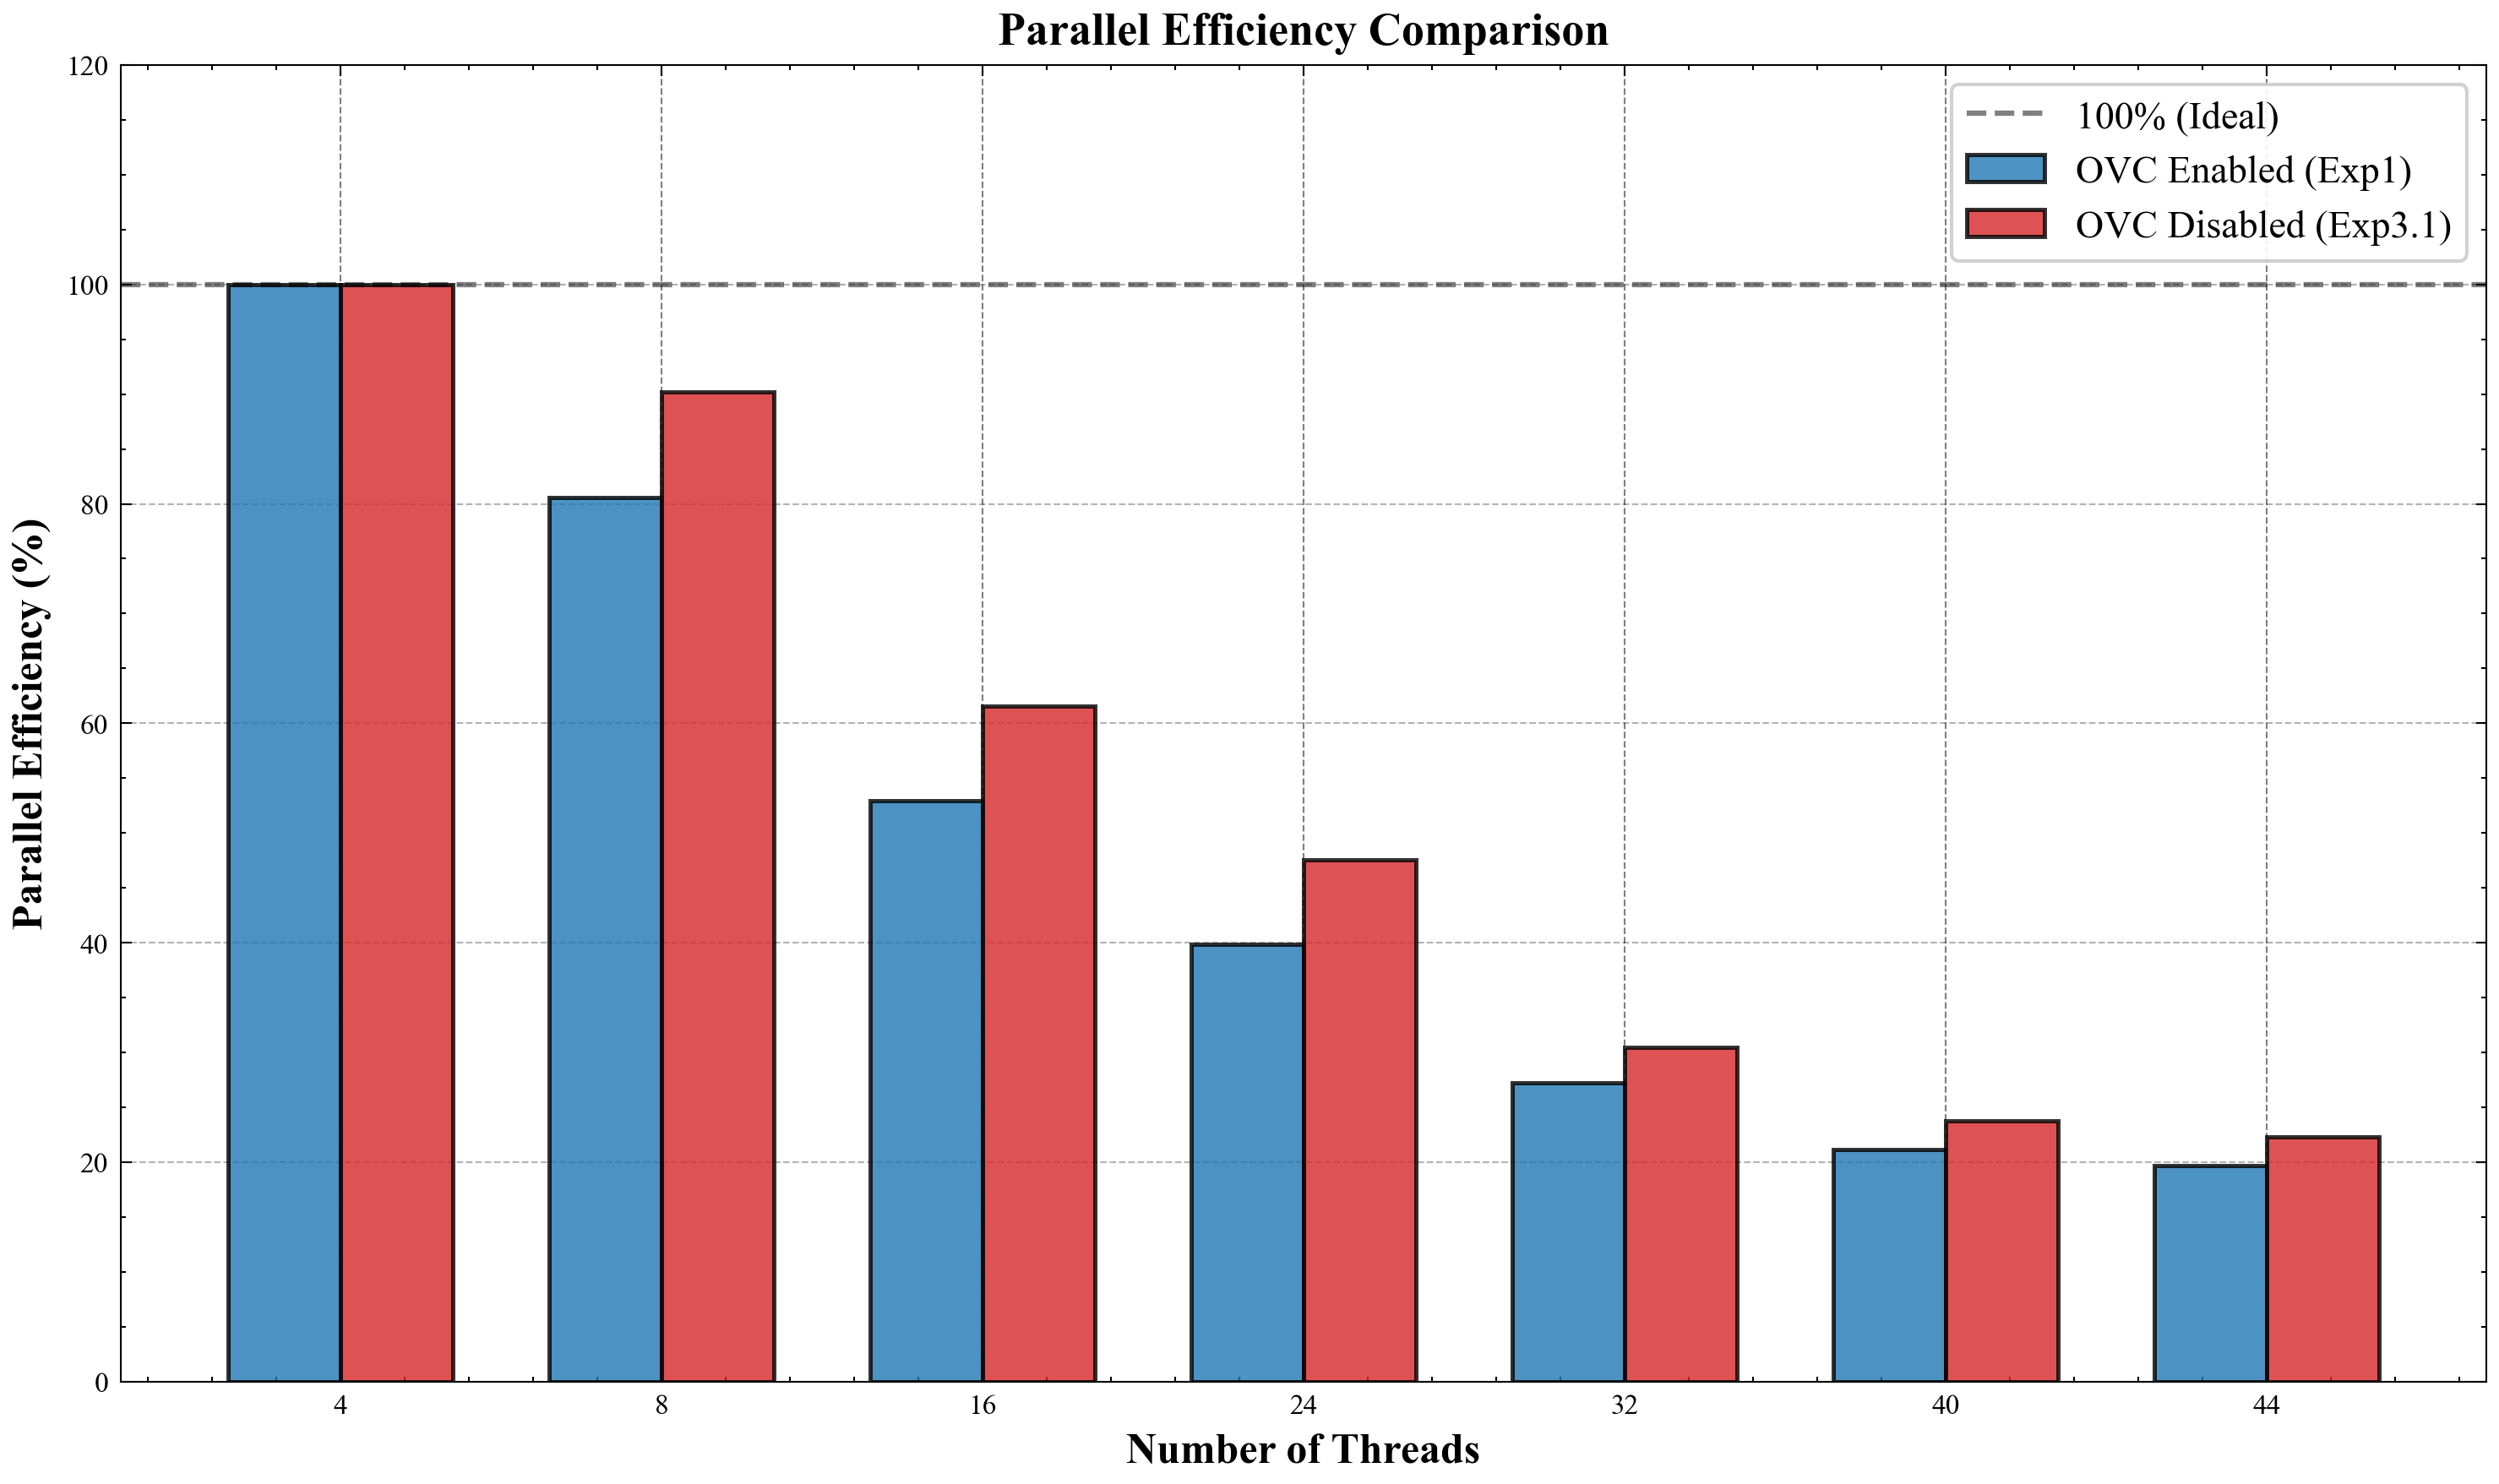


📊 Parallel Efficiency Comparison:
   OVC Enabled - Avg Efficiency: 48.8%
   OVC Disabled - Avg Efficiency: 53.7%


In [14]:
# Exp3.1 Plot 6: Parallel Efficiency
if len(df_exp3_1) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    df_exp1_sorted = df_exp1.sort_values('threads')
    df_exp3_1_sorted = df_exp3_1.sort_values('threads')
    
    baseline_threads = 4
    baseline_time_ovc = df_exp1_sorted[df_exp1_sorted['threads'] == baseline_threads]['total_time'].values[0]
    baseline_time_no_ovc = df_exp3_1_sorted[df_exp3_1_sorted['threads'] == baseline_threads]['total_time'].values[0]
    
    threads = df_exp1_sorted['threads'].values
    ideal_speedup = threads / baseline_threads
    
    speedup_ovc = baseline_time_ovc / df_exp1_sorted['total_time'].values
    speedup_no_ovc = baseline_time_no_ovc / df_exp3_1_sorted['total_time'].values
    
    efficiency_ovc = (speedup_ovc / ideal_speedup) * 100
    efficiency_no_ovc = (speedup_no_ovc / ideal_speedup) * 100
    
    width = 0.35
    x_pos = range(len(threads))
    
    ax.bar([x - width/2 for x in x_pos], efficiency_ovc, width, 
           label='OVC Enabled (Exp1)', color='#1f77b4', alpha=0.8, edgecolor='black', linewidth=1.2)
    ax.bar([x + width/2 for x in x_pos], efficiency_no_ovc, width, 
           label='OVC Disabled (Exp3.1)', color='#d62728', alpha=0.8, edgecolor='black', linewidth=1.2)
    
    ax.axhline(y=100, color='black', linestyle='--', lw=1.5, alpha=0.5, label='100% (Ideal)')
    ax.set_xlabel('Number of Threads', fontweight='bold', fontsize=12)
    ax.set_ylabel('Parallel Efficiency (%)', fontweight='bold', fontsize=12)
    ax.set_title('Parallel Efficiency Comparison', fontweight='bold', fontsize=13)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(threads)
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    ax.grid(True, linestyle='--', alpha=0.3, axis='y')
    ax.set_ylim(0, 120)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp3_1_efficiency.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n📊 Parallel Efficiency Comparison:")
    print(f"   OVC Enabled - Avg Efficiency: {efficiency_ovc.mean():.1f}%")
    print(f"   OVC Disabled - Avg Efficiency: {efficiency_no_ovc.mean():.1f}%")


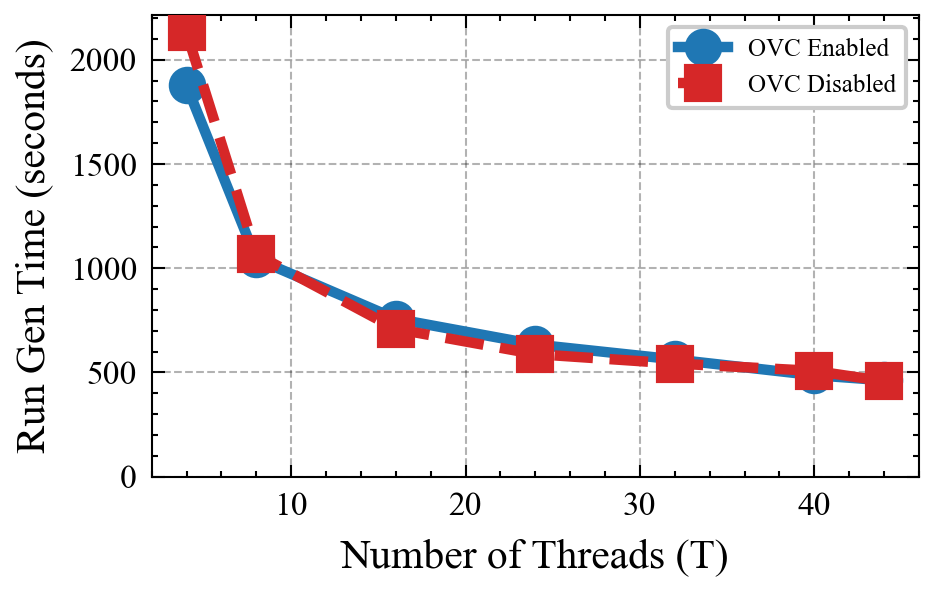

In [15]:
# Exp3.1 Plot 7: Run Generation Time Comparison
if len(df_exp3_1) > 0:
    fig, ax = plt.subplots()
    
    df_exp1_sorted = df_exp1.sort_values('threads')
    df_exp3_1_sorted = df_exp3_1.sort_values('threads')
    threads = df_exp1_sorted['threads'].values
    
    ax.plot(threads, df_exp1_sorted['rungen_time'], 'o-', lw=2.5, markersize=8, 
             color='#1f77b4', label='OVC Enabled', zorder=3)
    ax.plot(threads, df_exp3_1_sorted['rungen_time'], 's--', lw=2.5, markersize=8, 
             color='#d62728', label='OVC Disabled', zorder=3)
    
    ax.set_xlabel('Number of Threads (T)')
    ax.set_ylabel('Run Gen Time (seconds)')
    # ax.set_title('Run Generation Phase: OVC vs Non-OVC', fontweight='bold', fontsize=13)
    ax.legend(loc='best')
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.set_ylim(bottom=0)
    
    plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp3_1_rungen_time.png'), dpi=300)
    plt.show()


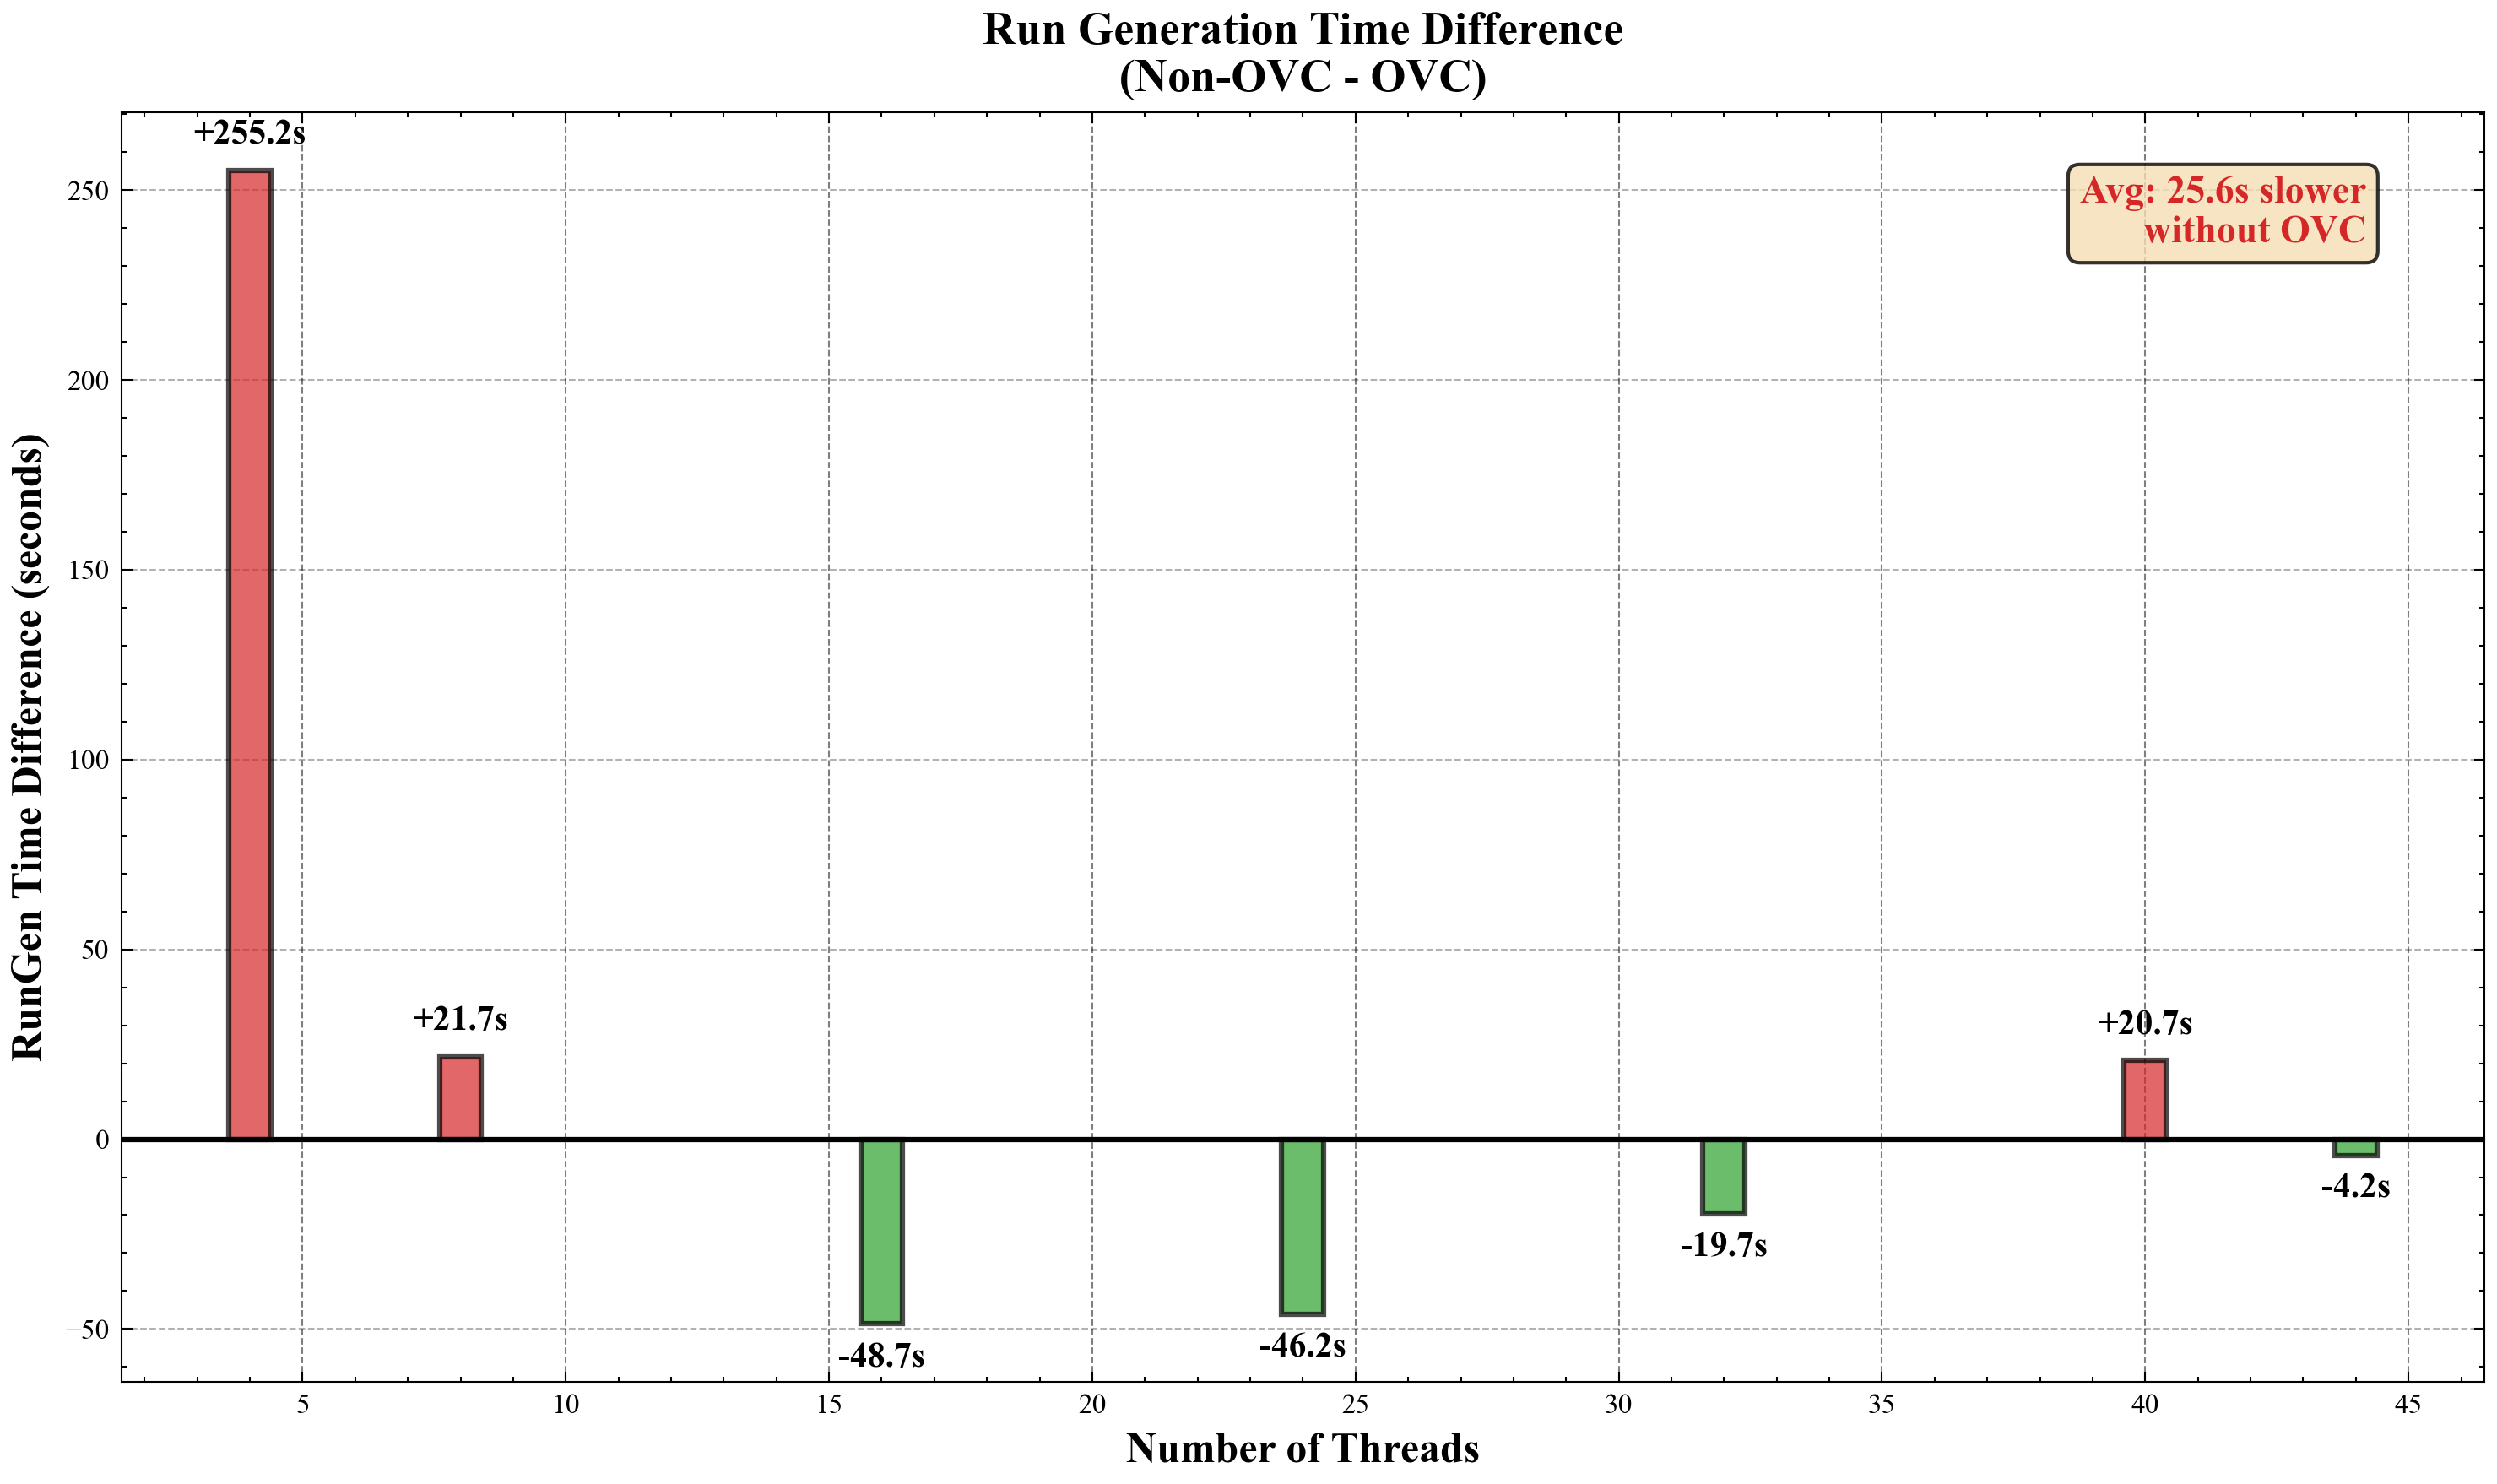


📊 Run Generation Time Analysis:
   Average RunGen diff: +25.6s (slower without OVC)
   Percentage change: +0.3%


In [16]:
# Exp3.1 Plot 8: Run Generation Time Difference
if len(df_exp3_1) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    df_exp1_sorted = df_exp1.sort_values('threads')
    df_exp3_1_sorted = df_exp3_1.sort_values('threads')
    threads = df_exp1_sorted['threads'].values
    
    rungen_diff = df_exp3_1_sorted['rungen_time'].values - df_exp1_sorted['rungen_time'].values
    bar_colors = ['#2ca02c' if diff < 0 else '#d62728' for diff in rungen_diff]
    
    bars = ax.bar(threads, rungen_diff, color=bar_colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    ax.axhline(y=0, color='black', linestyle='-', lw=1.5)
    
    for i, (thread, diff) in enumerate(zip(threads, rungen_diff)):
        label_y = diff + (5 if diff > 0 else -5)
        va = 'bottom' if diff > 0 else 'top'
        ax.text(thread, label_y, f'{diff:+.1f}s', 
                ha='center', va=va, fontweight='bold', fontsize=10)
    
    ax.set_xlabel('Number of Threads', fontweight='bold', fontsize=12)
    ax.set_ylabel('RunGen Time Difference (seconds)', fontweight='bold', fontsize=12)
    ax.set_title('Run Generation Time Difference\n(Non-OVC - OVC)', fontweight='bold', fontsize=13)
    ax.grid(True, linestyle='--', alpha=0.3, axis='y')
    
    avg_diff = rungen_diff.mean()
    text_color = '#2ca02c' if avg_diff < 0 else '#d62728'
    interpretation = 'faster' if avg_diff < 0 else 'slower'
    ax.text(0.95, 0.95, f'Avg: {abs(avg_diff):.1f}s {interpretation}\nwithout OVC', 
             transform=ax.transAxes, ha='right', va='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
             fontsize=11, color=text_color, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp3_1_rungen_diff.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\n📊 Run Generation Time Analysis:")
    print(f"   Average RunGen diff: {avg_diff:+.1f}s ({interpretation} without OVC)")
    pct_diff = (rungen_diff / df_exp1_sorted['rungen_time'].values * 100).mean()
    print(f"   Percentage change: {pct_diff:+.1f}%")


#### Exp3.1: Run Generation Time Analysis

### Plot 3: Exp3 - OVC vs NO-OVC Comparison

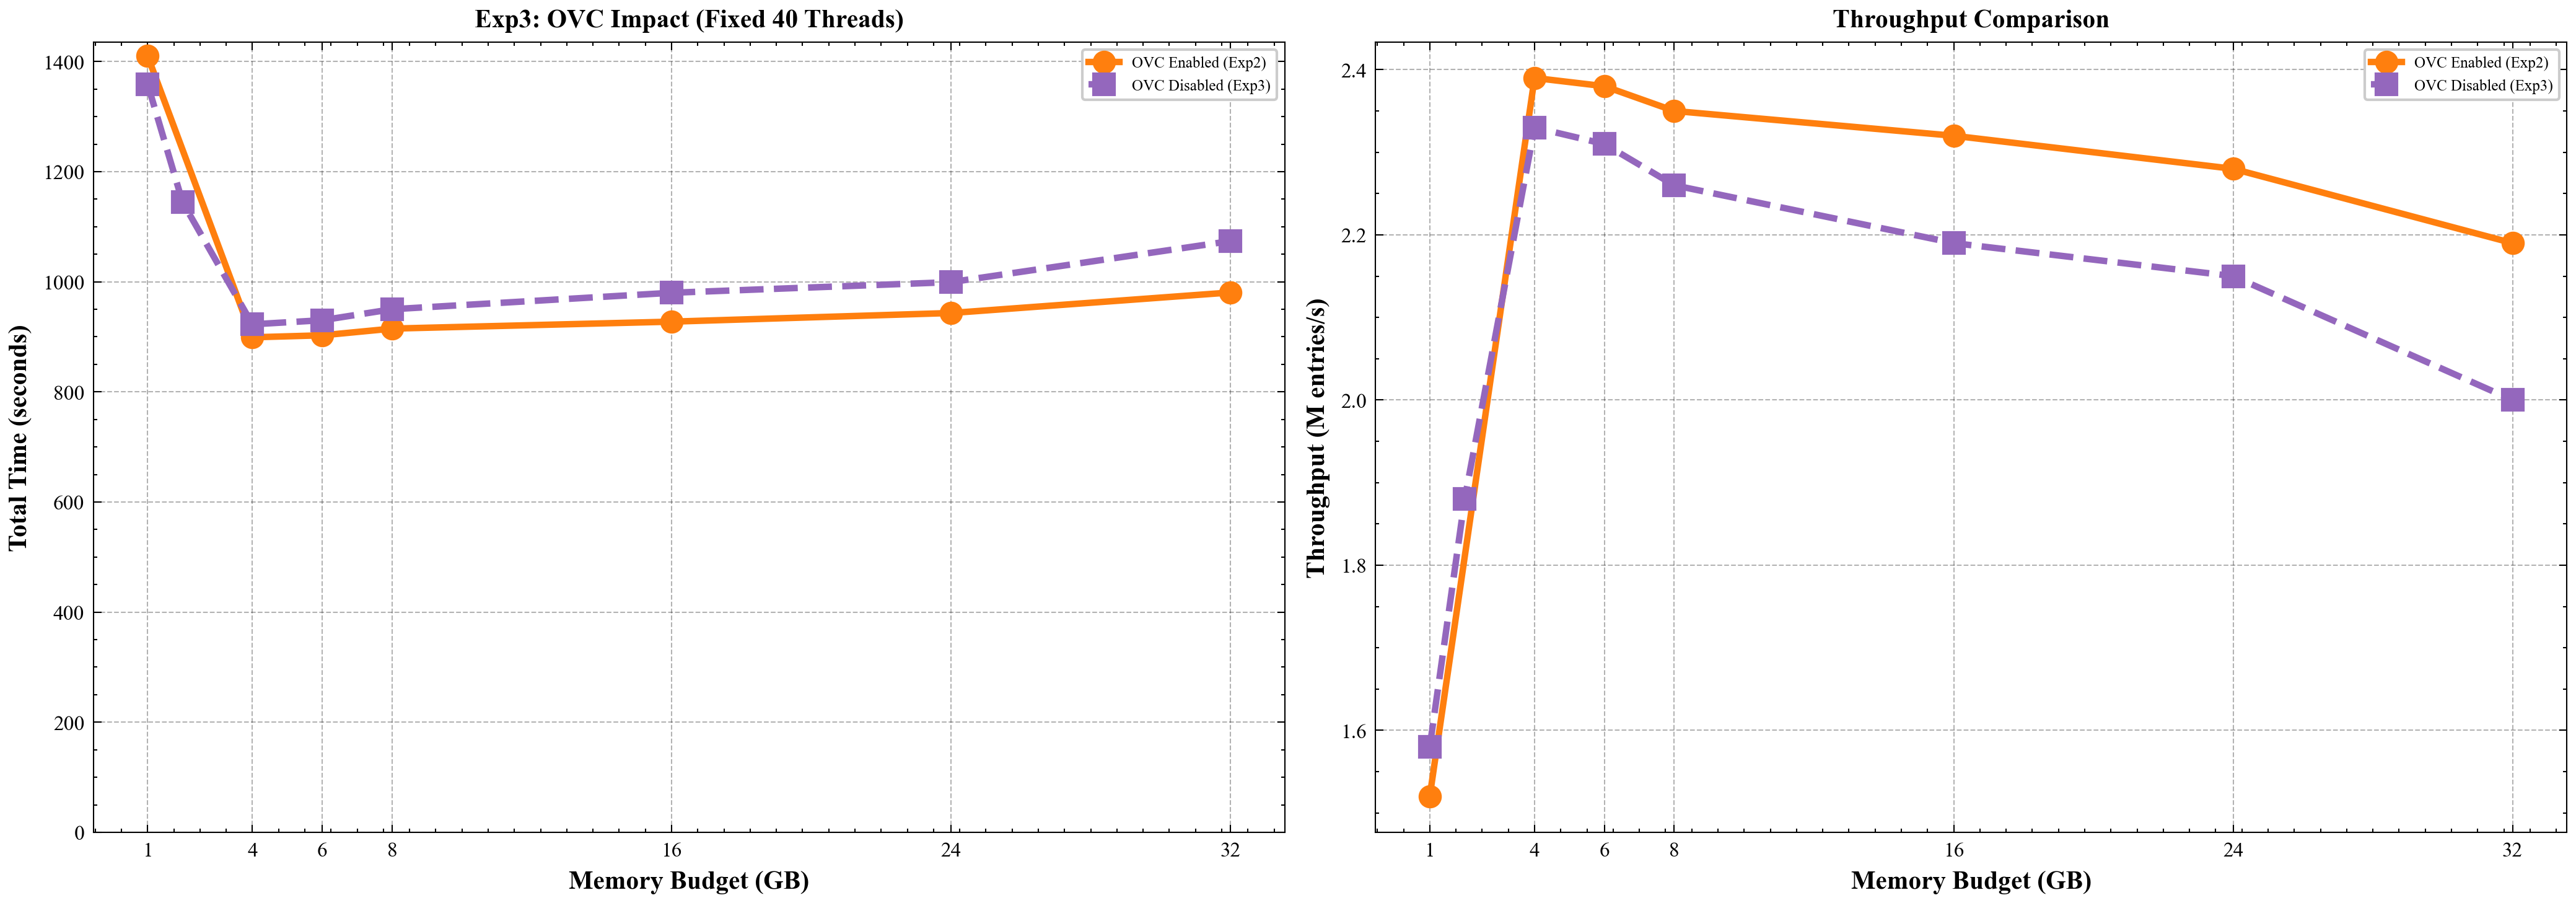


📊 Exp3 Insight: OVC provides 3.9% average speedup across memory configurations.


In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 3a: Total time comparison
df_exp2_sorted = df_exp2.sort_values('memory_gb')
df_exp3_sorted = df_exp3.sort_values('memory_gb')

ax1.plot(df_exp2_sorted['memory_gb'], df_exp2_sorted['total_time'], 
         'o-', lw=2.5, markersize=8, color=colors['exp2'], label='OVC Enabled (Exp2)')
ax1.plot(df_exp3_sorted['memory_gb'], df_exp3_sorted['total_time'], 
         's--', lw=2.5, markersize=8, color=colors['exp3'], label='OVC Disabled (Exp3)')

ax1.set_xlabel('Memory Budget (GB)', fontweight='bold')
ax1.set_ylabel('Total Time (seconds)', fontweight='bold')
ax1.set_title('Exp3: OVC Impact (Fixed 40 Threads)', fontweight='bold')
ax1.set_xticks(sorted(df_exp2_sorted['memory_gb'].unique()))
ax1.grid(True, linestyle='--', alpha=0.3)
ax1.legend(loc='best')
ax1.set_ylim(bottom=0)

# Plot 3b: Throughput comparison
ax2.plot(df_exp2_sorted['memory_gb'], df_exp2_sorted['throughput'], 
         'o-', lw=2.5, markersize=8, color=colors['exp2'], label='OVC Enabled (Exp2)')
ax2.plot(df_exp3_sorted['memory_gb'], df_exp3_sorted['throughput'], 
         's--', lw=2.5, markersize=8, color=colors['exp3'], label='OVC Disabled (Exp3)')

ax2.set_xlabel('Memory Budget (GB)', fontweight='bold')
ax2.set_ylabel('Throughput (M entries/s)', fontweight='bold')
ax2.set_title('Throughput Comparison', fontweight='bold')
ax2.set_xticks(sorted(df_exp2_sorted['memory_gb'].unique()))
ax2.grid(True, linestyle='--', alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'gensort_exp3_ovc_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

# Calculate OVC benefit
merged = pd.merge(df_exp2_sorted[['memory_gb', 'total_time']], 
                  df_exp3_sorted[['memory_gb', 'total_time']], 
                  on='memory_gb', suffixes=('_ovc', '_no_ovc'))
merged['speedup'] = (merged['total_time_no_ovc'] / merged['total_time_ovc'] - 1) * 100
avg_speedup = merged['speedup'].mean()
print(f"\n📊 Exp3 Insight: OVC provides {avg_speedup:.1f}% average speedup across memory configurations.")

### OVC vs NO-OVC: Phase Breakdown Analysis
